# Flow Matching 在双月牙数据上的训练与采样（对应书中 §12.4）

$$x_t=(1-t)\,x_0+t\,x_1,\qquad
\min_\theta\,\mathbb{E}_{t,x_0,x_1}\|v_\theta(x_t,t)-(x_1-x_0)\|^2,\qquad
\frac{dx}{dt}=v_\theta(x,t)$$

In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

def sample_moons(n):
    n1, n2 = n // 2, n - n // 2
    t1 = torch.rand(n1) * math.pi
    t2 = torch.rand(n2) * math.pi
    x1 = torch.stack([torch.cos(t1), torch.sin(t1)], dim=1)
    x2 = torch.stack([1 - torch.cos(t2), -torch.sin(t2) + 0.5], dim=1)
    x = torch.cat([x1, x2]) + 0.05 * torch.randn(n, 2)
    return (x - x.mean(0)) / x.std(0)

data = sample_moons(4096)

In [2]:
v_net = nn.Sequential(
    nn.Linear(3, 128), nn.SiLU(),
    nn.Linear(128, 128), nn.SiLU(),
    nn.Linear(128, 128), nn.SiLU(),
    nn.Linear(128, 2),
)
opt = torch.optim.Adam(v_net.parameters(), lr=2e-3)

for epoch in range(5001):
    x1 = data[torch.randint(0, len(data), (256,))]
    x0 = torch.randn(256, 2)
    t = torch.rand(256, 1)
    xt = (1 - t) * x0 + t * x1
    loss = ((v_net(torch.cat([xt, t], dim=1)) - (x1 - x0)) ** 2).mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    if epoch % 1000 == 0:
        print(f"epoch {epoch:5d}   loss = {loss.item():.4f}")

epoch     0   loss = 2.1216


epoch  1000   loss = 1.4287


epoch  2000   loss = 1.4012


epoch  3000   loss = 1.4391


epoch  4000   loss = 1.4963


epoch  5000   loss = 1.3470


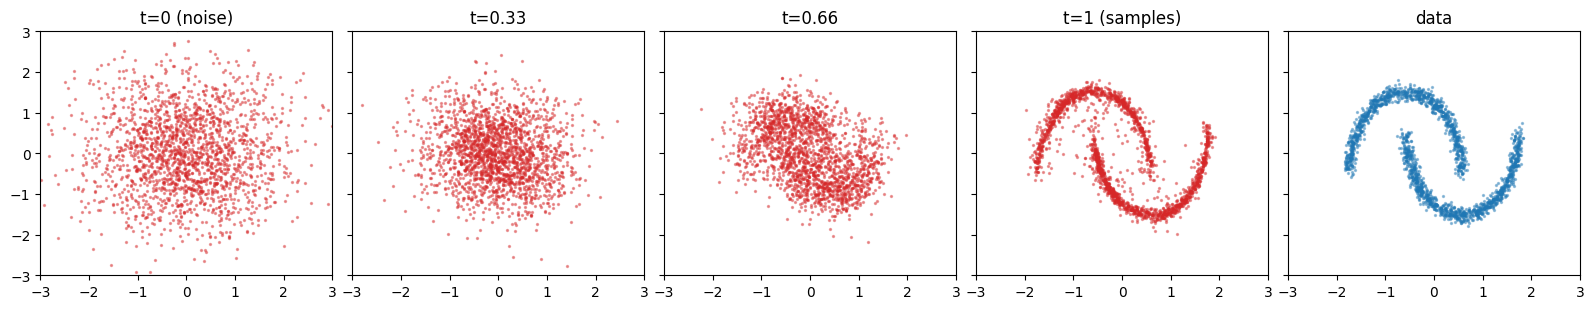

gen mean/std: [-0.019999999552965164, -0.004999999888241291] [0.9829999804496765, 1.0140000581741333]


In [3]:
@torch.no_grad()
def sample(n=2000, steps=100, keep=()):
    x = torch.randn(n, 2)
    snaps = {}
    dt = 1.0 / steps
    for i in range(steps):
        if i in keep:
            snaps[i] = x.clone()
        t = torch.full((n, 1), i * dt)
        x = x + dt * v_net(torch.cat([x, t], dim=1))
    return x, snaps

gen, snaps = sample(keep=(0, 33, 66))

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharex=True, sharey=True)
panels = [("t=0 (noise)", snaps[0]), ("t=0.33", snaps[33]), ("t=0.66", snaps[66]),
          ("t=1 (samples)", gen), ("data", data[torch.randperm(len(data))[:2000]])]
for ax, (title, pts) in zip(axes, panels):
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.4,
               color="tab:blue" if title == "data" else "tab:red")
    ax.set_title(title); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
plt.tight_layout(); plt.show()

print("gen mean/std:", gen.mean(0).round(decimals=3).tolist(), gen.std(0).round(decimals=3).tolist())